In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('events.csv')
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


In [3]:
df.shape

(885129, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [5]:
df["event_type"].value_counts()

event_type
view        793748
cart         54035
purchase     37346
Name: count, dtype: int64

In [6]:
df.isna().sum().sort_values(ascending=False)

category_code    236219
brand            212364
user_session        165
event_time            0
event_type            0
category_id           0
product_id            0
price                 0
user_id               0
dtype: int64

In [7]:
print("Date range:", df["event_time"].min(), "to", df["event_time"].max())
print("Unique users:", df["user_id"].nunique())
print("Unique sessions:", df["user_session"].nunique())
print("Unique products:", df["product_id"].nunique())
print("Duplicate rows:", df.duplicated().sum())

Date range: 2020-09-24 11:57:06 UTC to 2021-02-28 23:59:09 UTC
Unique users: 407283
Unique sessions: 490398
Unique products: 53453
Duplicate rows: 655


In [8]:
df.groupby("event_type").agg(
    events=("event_type", "size"),
    users=("user_id", "nunique"),
    sessions=("user_session", "nunique")
)

,events,users,sessions
event_type,,,
cart,54035,36952,41270
purchase,37346,21304,24344
view,793748,406863,488360


### Initial observations
- The dataset contains ___ events across ___ users and ___ sessions.
- Most events are ___, while purchases represent ___% of all events.
- Missing values are concentrated in ___, so this field will be handled carefully rather than dropping all affected rows.

In [9]:
df_clean = (
    df.drop_duplicates()
      .dropna(subset=["event_time", "event_type", "product_id", "user_id", "user_session"])
      .copy()
)

In [10]:
df_clean[["brand", "category_code"]] = (df_clean[["brand", "category_code"]].fillna("unknown"))
df_clean["category"] = df_clean["category_code"].str.split(".").str[0]

In [11]:
print("Original rows:", len(df))
print("Clean rows:", len(df_clean))

Original rows: 885129
Clean rows: 884312


In [12]:
df_clean["event_type"].value_counts()

event_type
view        792943
cart         54026
purchase     37343
Name: count, dtype: int64

### Cleaning decisions
- Removed duplicate events and rows missing identifiers needed for journey analysis.
- Retained missing brand and category values as `unknown` to avoid losing valid behavior data.

In [13]:
session_events = df_clean.pivot_table(
    index="user_session",
    columns="event_type",
    values="product_id",
    aggfunc="size",
    fill_value=0
)

In [14]:
view_sessions = df_clean[df_clean["event_type"] == "view"]["user_session"].nunique()
cart_sessions = df_clean[df_clean["event_type"] == "cart"]["user_session"].nunique()
purchase_sessions = df_clean[df_clean["event_type"] == "purchase"]["user_session"].nunique()

funnel = pd.DataFrame({
    "stage": ["View", "Cart", "Purchase"],
    "sessions": [view_sessions, cart_sessions, purchase_sessions]
})

funnel

,stage,sessions
0,View,488360
1,Cart,41270
2,Purchase,24344


In [15]:
view_to_cart = cart_sessions / view_sessions
cart_to_purchase = purchase_sessions / cart_sessions
view_to_purchase = purchase_sessions / view_sessions

print(f"View → Cart conversion: {view_to_cart:.2%}")
print(f"Cart → Purchase conversion: {cart_to_purchase:.2%}")
print(f"View → Purchase conversion: {view_to_purchase:.2%}")

View → Cart conversion: 8.45%
Cart → Purchase conversion: 58.99%
View → Purchase conversion: 4.98%


## Funnel Insight

- ___% of sessions that viewed a product added an item to cart.
- ___% of cart sessions resulted in a purchase.
- The largest drop-off occurs between ___ and ___.

In [16]:
views_by_category = df_clean[df_clean["event_type"] == "view"].groupby("category")["user_session"].nunique()
carts_by_category = df_clean[df_clean["event_type"] == "cart"].groupby("category")["user_session"].nunique()
purchases_by_category = df_clean[df_clean["event_type"] == "purchase"].groupby("category")["user_session"].nunique()

category_funnel = pd.DataFrame({
    "view_sessions": views_by_category,
    "cart_sessions": carts_by_category,
    "purchase_sessions": purchases_by_category
}).fillna(0)

category_funnel["view_to_purchase_rate"] = (
    category_funnel["purchase_sessions"] / category_funnel["view_sessions"]
)

category_funnel.sort_values("view_sessions", ascending=False).head(10)

,view_sessions,cart_sessions,purchase_sessions,view_to_purchase_rate
category,,,,
unknown,149524,8785,5284.0,0.035339
computers,148481,19588,10964.0,0.073841
electronics,103281,7614,4679.0,0.045304
stationery,26926,2492,1748.0,0.064919
appliances,25303,1010,617.0,0.024384
auto,19698,1257,738.0,0.037466
construction,17602,1154,655.0,0.037212
furniture,2146,139,85.0,0.039609
country_yard,1831,39,18.0,0.009831


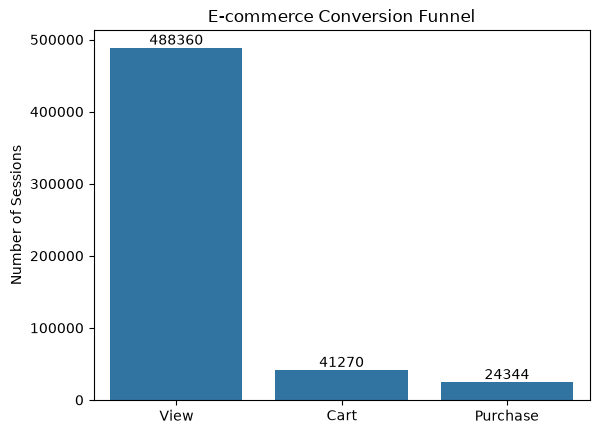

In [ ]:
sns.barplot(data = funnel, x = "stage", y = "sessions")
for i in range(len(funnel)):
    plt.text(i, funnel["sessions"][i], str(funnel["sessions"][i]), ha = "center", va = "bottom")
plt.title("E-commerce Conversion Funnel")
plt.xlabel("")
plt.ylabel("Number of Sessions")
plt.show()

## Key Findings

1. Out of all sessions with a product view, **X%** added an item to cart.
2. Only **Y%** of cart sessions resulted in a purchase.
3. The largest funnel drop-off occurred between **[View and Cart / Cart and Purchase]**.
4. **[Category name]** had high customer interest but a relatively low purchase-conversion rate, making it a potential improvement opportunity.

## Recommendations

1. Investigate the largest drop-off stage—for example, improve product information, pricing clarity, delivery messaging, or checkout usability.
2. Prioritise the low-converting, high-traffic category for a product experiment.
3. Validate any change with an A/B test using purchase conversion as the primary metric.